## Uncertainty quantification of tranmission coefficients with KDUQ 

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Latex, Math, display
from periodictable import elements

In [2]:
from matplotlib import pyplot as plt

## Compare models to KD

In [3]:
A, Z = (24, 12)

In [4]:
name_core = str(elements[Z].symbol)
display(Math(f"^{{{A}}} \\rm{{{name_core}}}"))

<IPython.core.display.Math object>

## Transmission coefficients
Let's use `jitr` to calculate UQ'ed transmission coefficients using KDUQ Fermi energies and those from a variety of mass models

In [5]:
from tqdm import tqdm

import jitr

In [6]:
neutron = (1, 0)
proton = (1,1)
projectile = proton
target = (A, Z)

In [7]:
# we have 416 samples from the KDUQ posterior
kduq_omp_samples = jitr.optical_potentials.kduq.get_samples_democratic(proton)

In [8]:
# com_energy_grid = np.logspace(-1, 1.3, 100)
com_energy_grid = np.array([65, 200])
range_fm = max(10,jitr.utils.interaction_range(A)*2)
lmax = 20
print(range_fm)

10


In [9]:
reaction = jitr.reactions.Reaction(target=target, projectile=projectile, process="EL")

In [10]:
def set_up_grid(core, com_energy_grid):
    solvers = []
    mn = jitr.utils.constants.MASS_N
    mcore = jitr.utils.mass.mass(*core)[0]
    for i, Ecm in enumerate(tqdm(com_energy_grid)):
        kinematics = jitr.utils.kinematics.classical_kinematics_cm(mcore, mn, Ecm)

        a = range_fm * kinematics.k + np.pi / 2
        
        N = jitr.utils.suggested_basis_size(a)
        solvers.append(
            jitr.xs.elastic.IntegralWorkspace(
                reaction=reaction,
                kinematics=kinematics,
                channel_radius_fm=a / kinematics.k,
                solver=jitr.rmatrix.Solver(N),
                lmax=lmax,
                smatrix_abs_tol=0,
            )
        )
    return solvers

In [11]:
solvers = set_up_grid(target, com_energy_grid)

100%|██████████| 2/2 [00:07<00:00,  3.76s/it]


## Run UQ

In [12]:
kduq_omp_samples.shape

(416, 40)

### KDUQ

In [14]:
tcoeff_kduq = np.zeros((com_energy_grid.size, kduq_omp_samples.shape[0], 2, lmax))
for j, sample in enumerate(tqdm(kduq_omp_samples)):

    for i, Ecm in enumerate(com_energy_grid):
        coulomb_params, scalar_params, spin_orbit_params = jitr.optical_potentials.kduq.calculate_params(
            projectile,
            target,
            solvers[i].kinematics.Elab,
            *sample,
        )

        tplus, tminus = solvers[i].transmission_coefficients(
            jitr.optical_potentials.kduq.central_plus_coulomb,
            jitr.optical_potentials.kduq.spin_orbit,
            (scalar_params, coulomb_params),
            spin_orbit_params,
        )
        tcoeff_kduq[i, j, 0, :] = tplus
        tcoeff_kduq[i, j, 1, :] = tminus

 15%|█▍        | 61/416 [00:07<00:18, 19.64it/s]/mnt/ffs24/home/beyerkyl/jitr/src/jitr/optical_potentials/kduq.py:397: RuntimeWarning: overflow encountered in exp
  d2 = d2_0 + d2_A / (1 + np.exp((A - d2_A3) / d2_A2))
100%|██████████| 416/416 [00:09<00:00, 41.99it/s] 


In [15]:
data = [np.zeros(20)] * 8
names = [
    "E=65 MeV, j = l + 1/2",
    "E=65 MeV, j = l - 1/2",
    "E=65 MeV, j = l + 1/2, err",
    "E=65 MeV, j = l - 1/2, err",
    "E=200 MeV, j = l + 1/2",
    "E=200 MeV, j = l - 1/2",
    "E=200 MeV, j = l + 1/2, err",
    "E=200 MeV, j = l - 1/2, err",
]

In [16]:
from pandas import DataFrame as df

In [17]:
data = df.from_dict(dict(zip(names, data)))

In [18]:
plus_color = "tab:blue"
minus_color = "tab:orange"

In [19]:
ci_plus = np.percentile(tcoeff_kduq[0, :, 0, :], 50, axis=0)
ci_plus_errs = np.percentile(tcoeff_kduq[0, :, 0, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[0, :, 0, :], 16, axis=0
)

In [20]:
ci_minus = np.percentile(tcoeff_kduq[0, :, 1, :], 50, axis=0)
ci_minus_errs = np.percentile(tcoeff_kduq[0, :, 1, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[0, :, 1, :], 16, axis=0
)

In [21]:
ci_minus[0] = None
ci_minus_errs[0] = None

In [22]:
data["E=65 MeV, j = l + 1/2"] = ci_plus
data["E=65 MeV, j = l + 1/2, err"] = ci_plus_errs
data["E=65 MeV, j = l - 1/2"] = ci_minus
data["E=65 MeV, j = l - 1/2, err"] = ci_minus_errs

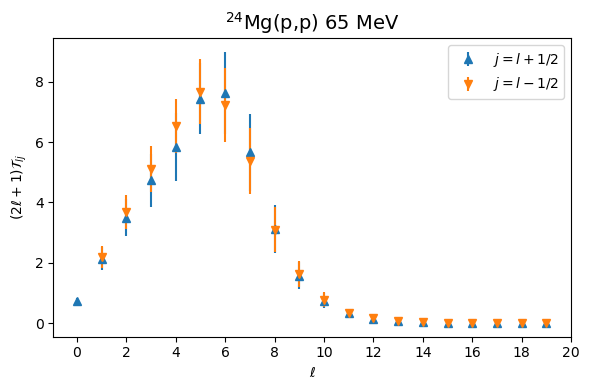

In [23]:
fig = plt.figure(figsize=(6, 4))
ls = np.arange(lmax)
plt.errorbar(
    ls,
    ci_plus * (2 * ls + 1),
    ci_plus_errs * (2 * ls + 1),
    linestyle="none",
    marker="^",
    label="$j = l + 1/2$",
)

plt.errorbar(
    ls[1:],
    ci_minus[1:] * (2 * ls[1:] + 1),
    ci_minus_errs[1:] * (2 * ls[1:] + 1),
    linestyle="none",
    marker="v",
    label="$j = l - 1/2$",
)

# plt.yscale("log")
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$(2  \ell +1) \mathcal{T}_{lj}$")
plt.title(r"$^{24}$Mg(p,p) 65 MeV", fontsize=14)
plt.legend()
plt.tight_layout()

In [24]:
ci_plus = np.percentile(tcoeff_kduq[1, :, 0, :], 50, axis=0)
ci_plus_errs = np.percentile(tcoeff_kduq[1, :, 0, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[1, :, 0, :], 16, axis=0
)

In [25]:
ci_minus = np.percentile(tcoeff_kduq[1, :, 1, :], 50, axis=0)
ci_minus_errs = np.percentile(tcoeff_kduq[1, :, 1, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[1, :, 1, :], 16, axis=0
)
ci_minus[0] = None
ci_minus_errs[0] = None

In [26]:
data["E=200 MeV, j = l + 1/2"] = ci_plus
data["E=200 MeV, j = l + 1/2, err"] = ci_plus_errs
data["E=200 MeV, j = l - 1/2"] = ci_minus
data["E=200 MeV, j = l - 1/2, err"] = ci_minus_errs

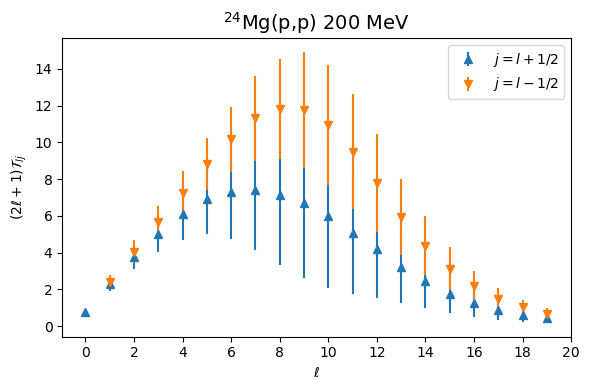

In [27]:
fig = plt.figure(figsize=(6, 4))
ls = np.arange(lmax)
plt.errorbar(
    ls,
    ci_plus * (2 * ls + 1),
    ci_plus_errs * (2 * ls + 1),
    linestyle="none",
    marker="^",
    label="$j = l + 1/2$",
)

plt.errorbar(
    ls[1:],
    ci_minus[1:] * (2 * ls[1:] + 1),
    ci_minus_errs[1:] * (2 * ls[1:] + 1),
    linestyle="none",
    marker="v",
    label="$j = l - 1/2$",
)

# plt.yscale("log")
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$(2  \ell +1) \mathcal{T}_{lj}$")
plt.title(r"$^{24}$Mg(p,p) 200 MeV", fontsize=14)
plt.legend()
plt.tight_layout()

In [28]:
#NBVAL_CHECK_OUTPUT
data

,"E=65 MeV, j = l + 1/2","E=65 MeV, j = l - 1/2","E=65 MeV, j = l + 1/2, err","E=65 MeV, j = l - 1/2, err","E=200 MeV, j = l + 1/2","E=200 MeV, j = l - 1/2","E=200 MeV, j = l + 1/2, err","E=200 MeV, j = l - 1/2, err"
0,0.724413,NaN,0.121112,NaN,0.786065,NaN,0.123251,NaN
1,0.711169,0.730115,0.125091,0.117178,0.770511,0.803983,0.127443,0.122135
2,0.697920,0.736503,0.123581,0.110344,0.750327,0.809946,0.133914,0.123189
3,0.676080,0.731309,0.125999,0.108599,0.718974,0.809216,0.145254,0.124648
4,0.647637,0.726927,0.124330,0.099829,0.680028,0.806652,0.159028,0.128858
5,0.676017,0.696813,0.106853,0.097791,0.627253,0.800574,0.173532,0.128765
6,0.586438,0.555806,0.105459,0.094672,0.560437,0.782508,0.194467,0.136089
7,0.377887,0.357624,0.084977,0.072554,0.494707,0.753288,0.217430,0.152737
8,0.182970,0.182196,0.046740,0.043201,0.418313,0.694565,0.223490,0.161258
9,0.082652,0.085247,0.023966,0.022677,0.351862,0.619929,0.213325,0.165955
